In [1]:
import os
import pickle
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix


In [2]:
# this is with retraining both first and second stage model, but with deleting output files from previous runs

results_dir = '/Users/eagle/Documents/eagle-classification/results_3'  
pickle_files = [f for f in os.listdir(results_dir) if f.endswith('.pkl') or f.endswith('.pickle')]

pred_labels_all = []
true_labels_all = []
for fname in pickle_files:
    file_path = os.path.join(results_dir, fname)
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
        pred_labels_all.extend(data['pred_labels'])
        true_labels_all.extend(data['true_labels'])

In [3]:
pred_labels_all = np.array(pred_labels_all)
true_labels_all = np.array(true_labels_all)


In [4]:

n_cols = pred_labels_all.shape[1]
for col in range(n_cols):
    col_preds = pred_labels_all[:, col]
    col_trues = true_labels_all[:, col]
    print(f"  Column {col}:")
    print("    Accuracy:", accuracy_score(col_trues, col_preds))
    print("    Precision:", precision_score(col_trues, col_preds, average='weighted', zero_division=0))
    print("    Recall:", recall_score(col_trues, col_preds, average='weighted', zero_division=0))
    print("    F1 Score:", f1_score(col_trues, col_preds, average='weighted', zero_division=0))
    print(classification_report(col_trues, col_preds, zero_division=0))
    print("    Confusion Matrix:")
    print(confusion_matrix(col_trues, col_preds))
    print("\n")

  Column 0:
    Accuracy: 0.9268171257882509
    Precision: 0.9290324652692487
    Recall: 0.9268171257882509
    F1 Score: 0.9276524968180375
              precision    recall  f1-score   support

         0.0       0.96      0.94      0.95      4678
         1.0       0.82      0.87      0.84      1348

    accuracy                           0.93      6026
   macro avg       0.89      0.91      0.90      6026
weighted avg       0.93      0.93      0.93      6026

    Confusion Matrix:
[[4412  266]
 [ 175 1173]]


  Column 1:
    Accuracy: 0.9352804513773647
    Precision: 0.9341042698497976
    Recall: 0.9352804513773647
    F1 Score: 0.9342401555029406
              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96      4712
         1.0       0.88      0.81      0.85      1314

    accuracy                           0.94      6026
   macro avg       0.92      0.89      0.90      6026
weighted avg       0.93      0.94      0.93      6026

    Confu

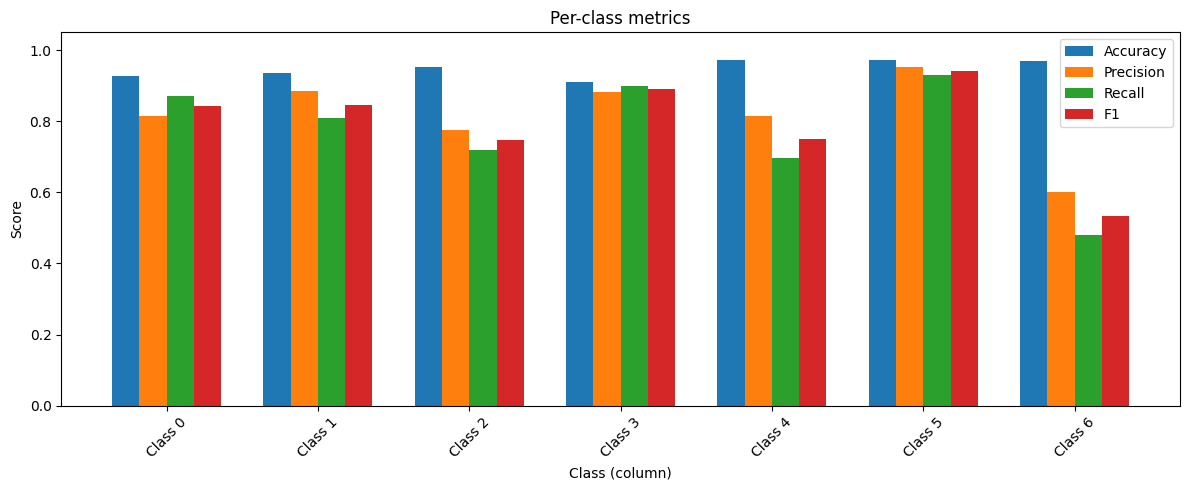

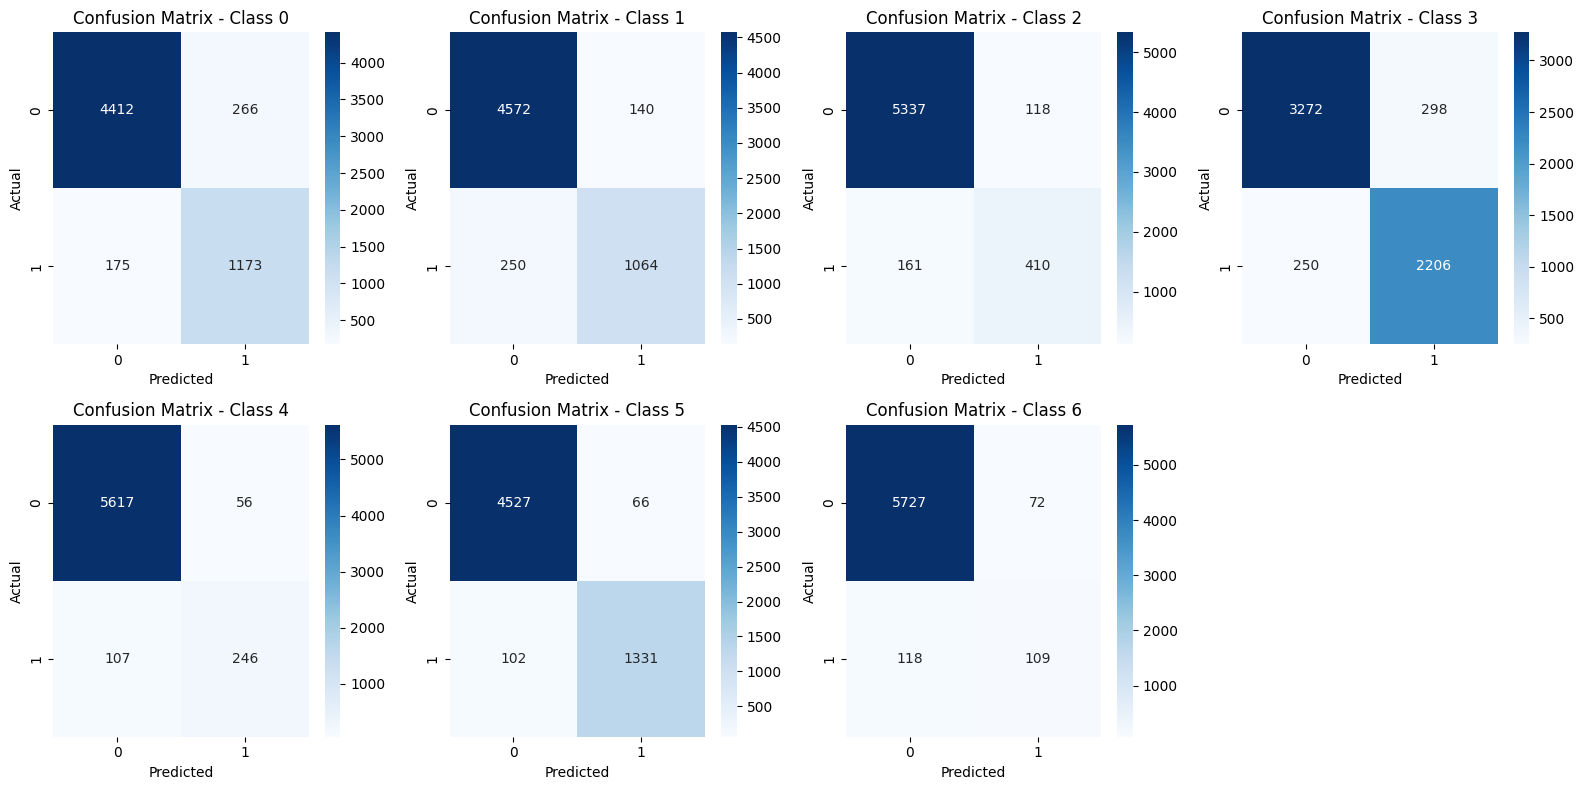

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# pred_labels_all and true_labels_all are expected to be numpy arrays from previous cells
n_cols = pred_labels_all.shape[1]

# Compute metrics per column
accs = []
precs = []
recs = []
f1s = []
conf_matrices = []

for col in range(n_cols):
    y_pred = pred_labels_all[:, col]
    y_true = true_labels_all[:, col]
    accs.append(accuracy_score(y_true, y_pred))
    precs.append(precision_score(y_true, y_pred, zero_division=0))
    recs.append(recall_score(y_true, y_pred, zero_division=0))
    f1s.append(f1_score(y_true, y_pred, zero_division=0))
    conf_matrices.append(confusion_matrix(y_true, y_pred))

cols = np.arange(n_cols)

# Plot bar chart of metrics
plt.figure(figsize=(12, 5))
width = 0.18
plt.bar(cols - 1.5*width, accs, width, label='Accuracy')
plt.bar(cols - 0.5*width, precs, width, label='Precision')
plt.bar(cols + 0.5*width, recs, width, label='Recall')
plt.bar(cols + 1.5*width, f1s, width, label='F1')
plt.xticks(cols, [f'Class {i}' for i in cols], rotation=45)
plt.ylim(0, 1.05)
plt.xlabel('Class (column)')
plt.ylabel('Score')
plt.title('Per-class metrics')
plt.legend()
plt.tight_layout()
plt.show()

# Plot confusion matrices (2x2) in a grid
n_rows = int(np.ceil(n_cols / 4))
fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i in range(len(axes)):
    if i < n_cols:
        cm = conf_matrices[i]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
        axes[i].set_title(f'Confusion Matrix - Class {i}')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')
    else:
        axes[i].axis('off')

plt.tight_layout()
plt.show()